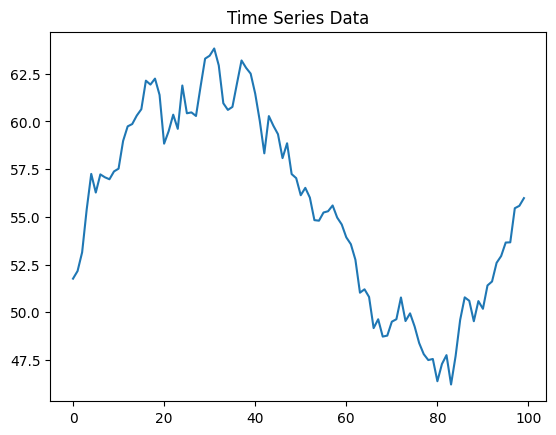

ADF Statistic: -1.1320384625097892
p-value: 0.7021277385898387
데이터는 불안정하여 차분이 필요합니다.
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -139.082
Date:                Tue, 29 Oct 2024   AIC                            284.163
Time:                        20:37:14   BIC                            291.949
Sample:                             0   HQIC                           287.313
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9450      0.082     11.491      0.000       0.784       1.106
ma.L1         -0.8819      0.115     -7.687   

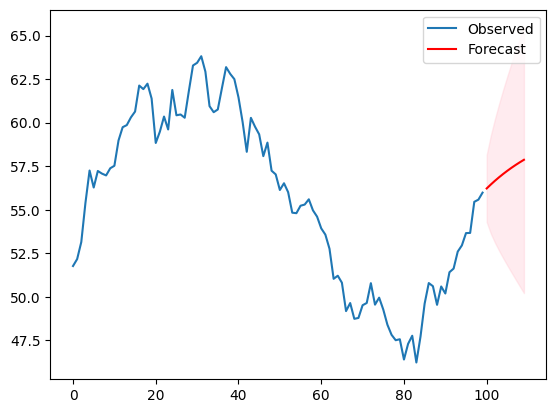

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

# 예제 시계열 데이터 생성 (실제 데이터가 있다면 이를 사용)
np.random.seed(0)
data = np.cumsum(np.random.randn(100)) + 50  # 랜덤 시계열 데이터 생성
df = pd.Series(data)

# 1. 데이터 시각화
df.plot(title="Time Series Data")
plt.show()

# 2. 데이터가 안정적인지 확인 (ADF 테스트)
result = adfuller(df)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] < 0.05:
    print("데이터는 안정적입니다.")
else:
    print("데이터는 불안정하여 차분이 필요합니다.")

# 3. ARIMA 모델 학습
# p, d, q 값을 설정 (예: p=1, d=1, q=1)
model = ARIMA(df, order=(1, 1, 1))
arima_result = model.fit()

# 4. 모델 요약 및 결과 확인
print(arima_result.summary())

# 5. 예측 수행
forecast = arima_result.get_forecast(steps=10)
forecast_ci = forecast.conf_int()

# 6. 예측 시각화
plt.figure()
plt.plot(df, label='Observed')
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.show()

In [23]:
#ARIMA and exchange_rate
import os, re

task_name='long_term_forecast'
model_id='COMPARE_iTransformer_Exchange_96_96'
model = 'iTransformer'
data_path = 'exchange_rate.csv'
seq_len=96
pred_len = 96
ii = 0

base_setting = r'{}_{}_Mod-{}_data-{}_({}to{})_{}'.format(
    task_name,
    model_id,
    model,
    data_path,
    seq_len,
    pred_len,
    ii
)

base_pattern = base_setting.replace('(', r'\(').replace(')', r'\)')

directory_path = "./checkpoints/"

# 지정된 형식의 디렉토리 검색
matching_dirs = [d for d in os.listdir(directory_path) if re.match(base_pattern, d)]

In [21]:
base_pattern

'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_\\(96to96\\)_0'

In [24]:
matching_dirs

['long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729843862)',
 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729846795)',
 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729844794)',
 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729846858)',
 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729842406)',
 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1730257686)']

In [19]:
base_setting

'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0'

In [7]:
os.listdir(directory_path)

['long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729843862)',
 'long_term_forecast_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729736010)',
 'long_term_forecast_COMPARE_DLinear_Exchange_96_96_Mod-DLinear_data-exchange_rate.csv_(96to96)_ENSEMBLE',
 'long_term_forecast_COMPARE_iTransformer_linear_Exchange_96_96_Mod-iTransformer_linear_data-exchange_rate.csv_(96to96)_0(1729900000)',
 'long_term_forecast_COMPARE_iTransformer_linear_Exchange_96_96_Mod-iTransformer_linear_data-exchange_rate.csv_(96to96)_0(1729843056)',
 'long_term_forecast_COMPARE_iTransformer_linear_Exchange_96_96_Mod-iTransformer_linear_data-exchange_rate.csv_(96to96)_0(1729842658)',
 'long_term_forecast_COMPARE_iTransformer_Weather_96_720_Mod-iTransformer_data-weather.csv_(96to720)_ENSEMBLE',
 'long_term_forecast_Exchange_24_24_iTransformer_Mod-iTransformer_data-exchange_rate.csv_(24to24)_0(1729835146)',
 'long_term_forecast_CO

In [12]:
re.match(base_setting, 'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange_rate.csv_(96to96)_0(1729842406)')

In [13]:
base_setting

'long_term_forecast_COMPARE_iTransformer_Exchange_96_96_Mod-iTransformer_data-exchange.csv_(96to96)_0\\(.*\\)'